In [4]:
%load_ext autoreload 
%autoreload 2
%matplotlib inline
import json, os, cv2
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.interpolate import interp1d
from scipy import signal
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.gridspec import GridSpec 
import glob 
import seaborn as sns
from brokenaxes import brokenaxes
from scipy.ndimage import gaussian_filter
import ast
import scipy.stats as stats
from scipy.stats import f_oneway



import sys
sys.path.insert(0, 'C:/Users/nlab/Documents/GitHub/obstacle_avoidance')

import warnings
warnings.filterwarnings('ignore')
from src.base import BaseInput
from src.topcam import Topcam
from src.utils.auxiliary import find_index_in_list,flatten_series
from pipeline.helper_functions import list_columns,interpolate_array,flatten_list_of_arrays,calculate_quartiles,create_df_by_type,split_range_into_parts,get_mean_of_df,get_median_of_df,drop_nans_in_columns,create_consective_df_new,assign_date_index,symmetrize_y_axis,edge_outliers,create_df_by_type_nostart,find_consecutive_repeats,largest_sequentially_increasing_by_one_subarray,create_color_dict,smooth,create_monotonic_array,correct_trace
from pipeline.oa_calculations import distance_calcs,heading_calcs,cluster_obstacle,calculate_distances,df_tortuosity,deveation,lateral_error,start,redo_ts_trace,compute_tortuosity,angular_velocity_head,turn_direction,turn_to_obstacle,get_head_angle,head_angle_velocity,intial_lateral_error,avg_lateral_error,check_trial_for_obstalce_cross_df,distance_at_head_turn,zero_out_angle_target_port,angular_velocity_head_corner,intial_distance_to_obstacle,last_occurrence_indices,first_occurrence_indices,calculate_relative_distance_goal_ts
#from pipeline.oa_plotting_funcs import plot_arena,plot_orginal_obstacle,plot_obstacle_from_row
from pipeline.batch_process_oa import plot_oa
from pipeline.gaze_shift_functions import *
from pipeline.oa_with_cams_plotting_funcs import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
metadata_path = r"\\goeppert\Vol2\mike\metadata\gaze_shift\oa_cam_050725_test.json"

with open(metadata_path) as f:
            metadata = json.load(f)

dates_list = [i for i in list(metadata.keys()) if i != 'path']
path = metadata['path']

In [16]:
data_path = Path(path).expanduser()

In [17]:
for date in dates_list:
    use_animals = [k for k,v in metadata[date].items()]
    for ani in tqdm(use_animals,'animal'):
        for task in os.listdir(data_path / date / ani):
            ## imu 
            #import IMU data  
            imu_timestamps_path = [str(i) for i in list((data_path / date / ani/ task).rglob('*.csv')) if '_Ephys_BonsaiBoardTS' in str(i)][0]
            imu_path = [str(i) for i in list((data_path / date / ani/ task).rglob('*.bin')) if '_IMU' in str(i)][0]
            # Set up datatypes and names for each channel
            dtypes = np.dtype([
                ("acc_x",np.uint16),
                ("acc_y",np.uint16),
                ("acc_z",np.uint16),
                ("none1",np.uint16),
                ("gyro_x",np.uint16),
                ("gyro_y",np.uint16),
                ("gyro_z",np.uint16),
                ("none2",np.uint16)
            ])


            binary_in = pd.DataFrame(np.fromfile(imu_path, dtypes, -1, ''))
            binary_in = binary_in.drop(columns=['none1','none2'])
            # Convert to - 5V to + 5V (from ints)
            data = 10 * (binary_in.astype(float)/(2**16) - 0.5)

            # Downsample in time dimension
            imu_samprate = 30000 # fixed constant
            imu_dwnsmpl = 100 # imu_samprate is 30000, and we are using 100, therefore making it 30000/100 = 300hz. 
                              # if you want to boost up the temporal resolution up to 500hz, you can use 60.

            data = data.iloc[::imu_dwnsmpl]

            # Calculate new sample rate
            samp_freq = imu_samprate / imu_dwnsmpl

            # Alphabetize columns
            data = data.reindex(sorted(data.columns), axis=1)

            # Read in timestamps
            csv_data = pd.read_csv(imu_timestamps_path).squeeze()
            pdtime = pd.DataFrame(read_timestamp_series(csv_data))

            # Get first/last timepoint, num_samples
            t0 = pdtime.iloc[0,0]
            num_samp = np.size(data,0)

            # Samples start at t0, and are acquired at rate of
            # 'ephys_sample_rate'/ 'imu_downsample'
            newtime = list(np.array(t0 + np.linspace(0, num_samp-1, num_samp) / samp_freq))


            IMU = ImuOrientation()
            
            # Convert accelerometer to g
            zero_reading = 2.9
            sensitivity = 1.6
            acc = pd.DataFrame.to_numpy((data[['acc_x', 'acc_y', 'acc_z']]-zero_reading)*sensitivity)

            # Convert gyro to deg/sec
            gyro = pd.DataFrame.to_numpy((data[['gyro_x', 'gyro_y', 'gyro_z']] - pd.DataFrame.mean(data[['gyro_x', 'gyro_y', 'gyro_z']]))*400)

            # Collect roll & pitch
            roll_pitch = np.zeros([len(acc),2])
            for x in range(len(acc)):
                roll_pitch[x,:] = IMU.process((acc[x],gyro[x])) # update by row
            roll_pitch = pd.DataFrame(roll_pitch, columns=['roll','pitch'])

            # Collect the data together
            all_data = pd.concat([
                data.reset_index(),
                pd.DataFrame(acc).reset_index(),
                pd.DataFrame(gyro).reset_index(),
                roll_pitch
            ], axis=1).drop(labels='index',axis=1)

            # Set up column names
            all_data.columns = [
                'acc_x_raw','acc_y_raw','acc_z_raw',
                'gyro_x_raw','gyro_y_raw','gyro_z_raw',
                'acc_x','acc_y','acc_z',
                'gyro_x', 'gyro_y', 'gyro_z',
                'roll', 'pitch'
            ]
            output_data = xr.DataArray(all_data, dims=['sample','channel'])
            imu_data = output_data.assign_coords({'sample':newtime})
            
            imuT_raw = imu_data.sample # imu timestamps
            
            # Raw gyro values
            gyro_x_raw = imu_data.sel(channel='gyro_x_raw').values
            gyro_y_raw = imu_data.sel(channel='gyro_y_raw').values
            gyro_z_raw = imu_data.sel(channel='gyro_z_raw').values
            
            # Gyro values in degrees
            gyro_x = imu_data.sel(channel='gyro_x').values
            gyro_y = imu_data.sel(channel='gyro_y').values
            gyro_z = imu_data.sel(channel='gyro_z').values
            
            # Pitch and roll in deg
            roll = imu_data.sel(channel='roll').values
            pitch = imu_data.sel(channel='pitch').values


            

animal: 100%|██████████| 1/1 [01:11<00:00, 71.92s/it]


In [18]:
dlc_h5 = [str(i) for i in list((data_path / date / ani/ task).rglob('*.h5')) if 'REYEdeinterDLC' in str(i)][0]
eye_timestamp_path = [str(i) for i in list((data_path / date / ani/ task).rglob('*.csv')) if 'REYE_BonsaiTS.csv' in str(i)][0]
pts, pt_names = open_dlc_h5(dlc_h5)
eyeT = read_timestamp_file(eye_timestamp_path, len(pts))
xrpts = xr.DataArray(pts, dims=['frame', 'point_loc'])

data = xrpts
names = list(data['point_loc'].values)
thresh = 0.99 #configuration value

x_locs = []
y_locs = []
likeli_locs = []

# seperate the lists of point names into x, y, and likelihood
for loc_num in range(0, len(names)):
    loc = names[loc_num]
    if '_x' in loc:
        x_locs.append(loc)
    elif '_y' in loc:
        y_locs.append(loc)
    elif 'likeli' in loc:
        likeli_locs.append(loc)

# get the xarray, split up into x, y,and likelihood
for loc_num in range(0, len(likeli_locs)):
    pt_loc = likeli_locs[loc_num]
    if loc_num == 0:
        likeli_pts = data.sel(point_loc=pt_loc)
    elif loc_num > 0:
        likeli_pts = xr.concat([likeli_pts, data.sel(point_loc=pt_loc)],
                                dim='point_loc', fill_value=np.nan)

for loc_num in range(0, len(x_locs)):
    pt_loc = x_locs[loc_num]
    # threshold from likelihood
    data.sel(point_loc=pt_loc)[data.sel(point_loc=pt_loc) < thresh] = np.nan
    if loc_num == 0:
        x_pts = data.sel(point_loc=pt_loc)
    elif loc_num > 0:
        x_pts = xr.concat([x_pts, data.sel(point_loc=pt_loc)],
                            dim='point_loc', fill_value=np.nan)

for loc_num in range(0, len(y_locs)):
    pt_loc = y_locs[loc_num]
    # threshold from likelihood
    data.sel(point_loc=pt_loc)[data.sel(point_loc=pt_loc) < thresh] = np.nan
    if loc_num == 0:
        y_pts = data.sel(point_loc=pt_loc)
    elif loc_num > 0:
        y_pts = xr.concat([y_pts, data.sel(point_loc=pt_loc)],
                            dim='point_loc', fill_value=np.nan)

x_pts = xr.DataArray.squeeze(x_pts)
y_pts = xr.DataArray.squeeze(y_pts)
likeli_pts = xr.DataArray.squeeze(likeli_pts)

# convert to dataframe, transpose so points are columns
x_vals = xr.DataArray.to_pandas(x_pts).T
y_vals = xr.DataArray.to_pandas(y_pts).T
likeli_vals = xr.DataArray.to_pandas(likeli_pts).T
likelihood_in = likeli_vals.values

# Subtract center of IR light reflection from points around the pupil.

spot_xcent = np.mean(x_vals.iloc[:,-5:], 1)
spot_ycent = np.mean(y_vals.iloc[:,-5:], 1)
spot_likelihood = likelihood_in[:,-5:].copy()

likelihood = likelihood_in[:,:-5]

x_vals = x_vals.iloc[:,:-5].subtract(spot_xcent, axis=0)
y_vals = y_vals.iloc[:,:-5].subtract(spot_ycent, axis=0)

x_vals = x_vals.iloc[:,:-2]
y_vals = y_vals.iloc[:,:-2]
likelihood = likelihood[:,:-2]

pupil_count = np.sum(likelihood >= thresh, 1)

spot_count = np.sum(spot_likelihood >= thresh, 1)

usegood_eye = (pupil_count >= 7) &               \
                (spot_count >= 5)

usegood_eyecalib = (pupil_count >= 8) &          \
                    (spot_count >= 5)

usegood_reflec = (spot_count >=5)


# Threshold out pts more than a given distance away from nanmean of that point
std_thresh_x = np.empty(np.shape(x_vals))

for point_loc in range(0,np.size(x_vals, 1)):
    _val = x_vals.iloc[:,point_loc]
    std_thresh_x[:,point_loc] = (np.abs(np.nanmean(_val) - _val)                \
                    / 24) > 24

std_thresh_y = np.empty(np.shape(y_vals))

for point_loc in range(0,np.size(x_vals, 1)):
    _val = y_vals.iloc[:,point_loc]
    std_thresh_y[:,point_loc] = (np.abs(np.nanmean(_val) - _val)                \
                    / 24) > 4.1

std_thresh_x = np.nanmean(std_thresh_x, 1)
std_thresh_y = np.nanmean(std_thresh_y, 1)

x_vals[std_thresh_x > 0] = np.nan
y_vals[std_thresh_y > 0] = np.nan

cols = [
    'X0',           # 0
    'Y0',           # 1
    'F',            # 2
    'a',            # 3
    'b',            # 4
    'long_axis',    # 5
    'short_axis',   # 6
    'angle_to_x',   # 7
    'angle_from_x', # 8
    'cos_phi',      # 9
    'sin_phi',      # 10
    'X0_in',        # 11
    'Y0_in',        # 12
    'phi'           # 13
]

In [19]:
#Fit ellipse

ellipse = np.empty([len(usegood_eye), 14])

# Step through each frame, fit an ellipse to points, and add ellipse
# parameters to array with data for all frames together.
linalgerror = 0
for step in tqdm(range(0,len(usegood_eye))):
    
    if usegood_eye[step] == True:
        
        try:

            e_t = fit_ellipse(x_vals.iloc[step].values,
                                    y_vals.iloc[step].values)
            
            ellipse[step] = [
                e_t['X0'],              # 0
                e_t['Y0'],              # 1
                e_t['F'],               # 2
                e_t['a'],               # 3
                e_t['b'],               # 4
                e_t['long_axis'],       # 5
                e_t['short_axis'],      # 6
                e_t['angle_to_x'],      # 7
                e_t['angle_from_x'],    # 8
                e_t['cos_phi'],         # 9
                e_t['sin_phi'],         # 10
                e_t['X0_in'],           # 11
                e_t['Y0_in'],           # 12
                e_t['phi']              # 13
            ]
        
        except np.linalg.LinAlgError as e:

            linalgerror = linalgerror + 1
            ellipse[step] = list(np.ones([len(cols)]) * np.nan)
    
    elif usegood_eye[step] == False:

        ellipse[step] = list(np.ones([len(cols)]) * np.nan)

print('LinAlg error count = ' + str(linalgerror))

# List of all places where the ellipse meets threshold
R = np.linspace(0, 2*np.pi, 100)

# (short axis / long axis) < thresh
usegood_ellipcalb = np.where((usegood_eyecalib == True)                     \
        & ((ellipse[:,6] / ellipse[:,5]) < 0.85))

# Limit number of frames used for calibration
f_lim = 50000
if np.size(usegood_ellipcalb,1) > f_lim:
    shortlist = sorted(np.random.choice(usegood_ellipcalb[0],
                        size=f_lim, replace=False))
else:
    shortlist = usegood_ellipcalb

# Find camera center
A = np.vstack([np.cos(ellipse[shortlist,7]),
                np.sin(ellipse[shortlist,7])])

b = np.expand_dims(np.diag(A.T @ np.squeeze(ellipse[shortlist, 11:13].T)), axis=1)

cam_cent = np.linalg.inv(A @ A.T) @ A @ b

# Ellipticity and scale
ellipticity = (ellipse[shortlist,6] / ellipse[shortlist,5]).T

try:
    scale = np.nansum(np.sqrt(1 - (ellipticity)**2) *                       \
    (np.linalg.norm(ellipse[shortlist, 11:13] - cam_cent.T, axis=0)))       \
    / np.sum(1 - (ellipticity)**2)

except ValueError:

    scale = np.nansum(np.sqrt(1 - (ellipticity)**2) *                       \
    (np.linalg.norm(ellipse[shortlist, 11:13] - cam_cent.T, axis=1)))       \
    / np.sum(1 - (ellipticity)**2)


# Horizontal orientation (THETA)
theta = np.arcsin((ellipse[:,11] - cam_cent[0]) / scale)

# Vertical orientation (PHI)
phi = np.arcsin((ellipse[:,12] - cam_cent[1]) / np.cos(theta) / scale)

100%|██████████| 124408/124408 [00:46<00:00, 2697.46it/s]


LinAlg error count = 0


In [20]:
# Organize data to return as an xarray of most essential parameters
ellipse_df = pd.DataFrame({
    'theta':list(theta),
    'phi':list(phi),
    'longaxis':list(ellipse[:,5]),
    'shortaxis':list(ellipse[:,6]),
    'X0':list(ellipse[:,11]),
    'Y0':list(ellipse[:,12]),
    'ellipse_phi':list(ellipse[:,7])
})

ellipse_param_names = [
    'theta',
    'phi',
    'longaxis',
    'shortaxis',
    'X0',
    'Y0',
    'ellipse_phi'
]

ellipse_out = xr.DataArray(ellipse_df,
    coords=[('frame', range(0, len(ellipse_df))),
            ('ellipse_params', ellipse_param_names)],
    dims=['frame', 'ellipse_params'])

ellipse_out.attrs['cam_center_x'] = cam_cent[0,0]
ellipse_out.attrs['cam_center_y'] = cam_cent[1,0]

In [43]:
ellipse_out

<xarray.DataArray (frame: 124408, ellipse_params: 7)>
array([[        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       ...,
       [ 0.1484882 , -0.69518718, 22.68823348, ..., 18.06013241,
        -1.10394807, -2.74508439],
       [ 0.14829436, -0.69700727, 22.61140428, ..., 18.05048578,
        -1.17437916, -2.73769255],
       [ 0.14883522, -0.69537608, 22.52338916, ..., 18.07740177,
        -1.10950993, -2.73241843]])
Coordinates:
  * frame           (frame) int32 0 1 2 3 4 ... 124404 124405 124406 124407
  * ellipse_params  (ellipse_params) <U11 'theta' 'phi' ... 'Y0' 'ellipse_phi'
Attributes:
    cam_center_x:  10.61569243188819
    cam_center_y:  30.772549956537468

In [21]:
top_dlc_path = [str(i) for i in list((data_path / date / ani/ task).rglob('*.h5')) if '_TOP1DLC' in str(i)][0]
top_timestamp_path = [str(i) for i in list((data_path / date / ani/ task).rglob('*.csv')) if '_TOP1_BonsaiTS' in str(i)][0]
topT = read_timestamp_file(top_timestamp_path, len(pts))


In [22]:
shifted_head = 0
still_gaze = 120
shifted_gaze = 200

th = np.rad2deg(ellipse_out.sel(ellipse_params = 'theta').values)
theta = th - np.nanmean(th)
dEye = np.diff(theta)

In [23]:
##gyro x for timestamp correction 
                ## gyro z for dHead 
Openephys_time = read_timestamp_file(imu_timestamps_path)
OpenephysT0 = Openephys_time[0]
# match timestamps
pts, pt_names = open_dlc_h5(dlc_h5)
eyeT = read_timestamp_file(eye_timestamp_path, len(pts))
eyeT = eyeT - OpenephysT0
imuT_raw = imu_data.sample
imuT_raw = imuT_raw - OpenephysT0
topT = read_timestamp_file(top_timestamp_path, len(pts))
topT = topT - OpenephysT0
# account for the drift (it is a system known issue that open ephys box has a weird drift phenomenon)
lag_range = np.arange(-0.2, 0.2, 0.002)
cc = np.zeros(np.shape(lag_range))
t1 = np.arange(5, len(dEye)/60 - 120, 20).astype(int)
t2 = t1 + 60
offset = np.zeros(np.shape(t1))
ccmax = np.zeros(np.shape(t1))
imu_interp = scipy.interpolate.interp1d(imuT_raw, gyro_x)
for tstart in tqdm(range(len(t1))):

    for l in range(len(lag_range)):
        try:
            c, lag = nanxcorr(-dEye[t1[tstart]*60 : t2[tstart]*60],
                        imu_interp(eyeT[t1[tstart]*60 : t2[tstart]*60]+lag_range[l]),
                        1)
            cc[l] = c[1]
        except:
            cc[l] = np.nan
    offset[tstart] = lag_range[np.argmax(cc)]    
    ccmax[tstart] = np.max(cc)
offset[ccmax<0.2] = np.nan
# Fit regression to timing drift
model = sklearn.linear_model.LinearRegression()
dataT = np.array(eyeT[t1*60 + 30*60])
model.fit(dataT[~np.isnan(offset)].reshape(-1,1),
            offset[~np.isnan(offset)]) 
ephys_offset = model.intercept_
ephys_drift_rate = model.coef_
imuT = imuT_raw - (ephys_offset + imuT_raw * ephys_drift_rate)
tmp_eyeT = eyeT.flatten()[:-1]
# calculating eye movements
eye_use_thresh = 50
theta[np.where(abs(theta) > eye_use_thresh)] = np.nan
dEye_dps = dEye / np.diff(eyeT) # deg/sec
dEye_dps[np.where(abs(dEye_dps) >1500)] = np.nan
# Extract gaze/compensatory trials
dHead = scipy.interpolate.interp1d(imuT,
                                    gyro_z,
                                    bounds_error=False)(eyeT)[:-1]
dGaze = dHead + dEye_dps
gazeL = tmp_eyeT[(dHead > shifted_head) &         \
                 (dGaze > shifted_gaze)]
gazeR = tmp_eyeT[(dHead < -shifted_head) &        \
                 (dGaze < -shifted_gaze)]
compL = tmp_eyeT[(dHead > shifted_head) &         \
                 (dGaze < still_gaze) &           \
                 (dGaze > -still_gaze)]
compR = tmp_eyeT[(dHead < -shifted_head) &        \
                 (dGaze > -still_gaze) &          \
                 (dGaze < still_gaze)]
# Eliminating compensatory eye/head movements which fall right after gaze-shifting eye/head movements
#compL = drop_nearby_events(compL, gazeL)  
#compR = drop_nearby_events(compR, gazeR)
# Eliminate saccades repeated over sequential camera frames
gazeL_event = drop_repeat_events(gazeL)
gazeR_event = drop_repeat_events(gazeR)
compL_event = drop_repeat_events(compL)
compR_event = drop_repeat_events(compR)
# Extract idx
_, gazeL_idx, _ = np.intersect1d(tmp_eyeT,gazeL_event, return_indices=True)
_, gazeR_idx, _ = np.intersect1d(tmp_eyeT,gazeR_event, return_indices=True)
_, compL_idx, _ = np.intersect1d(tmp_eyeT,compL_event, return_indices=True)
_, compR_idx, _ = np.intersect1d(tmp_eyeT,compR_event, return_indices=True)

100%|██████████| 98/98 [01:36<00:00,  1.01it/s]


In [40]:
Path(data_path / date / ani/ task)

WindowsPath('//goeppert/Vol2/mike/recordings/050725/F3LILT/oa_cam')

In [24]:
animal_directory = Path(data_path / date / ani/ task)
save_imu_eye_data(directory=animal_directory,Openephys_time =Openephys_time,
                  animal=ani, date=date,Usegood_reflec=usegood_reflec,spot_count=spot_count,
                  dEye_dps=dEye_dps,dHead=dHead,imuT=imuT,dGaze=dGaze,gazeL_event=gazeL_event,gazeL_idx=gazeL_idx,gazeR_event= gazeR_event,gazeR_idx=gazeR_idx,
                  compL_event=compL_event,compL_idx=compL_idx,compR_event = compR_event, compR_idx=compR_idx, filename= str(date)+ "_"+str(ani)+"_imu_eyecam_dict")

AttributeError: 'NoneType' object has no attribute 'to_dict'

Text(0, 0.5, 'fraction of frames')

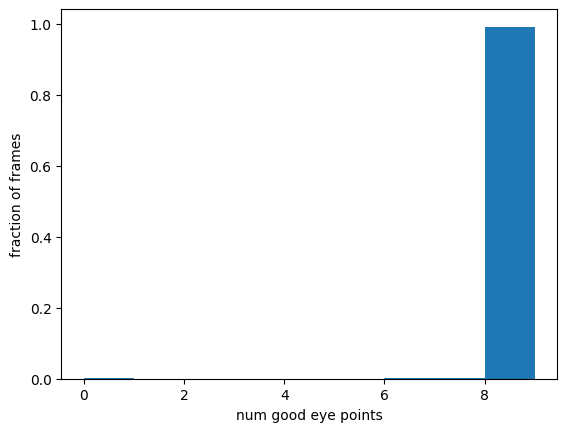

In [47]:
plt.figure()
plt.hist(pupil_count, bins=9,
                range=(0,9), density=True)
plt.xlabel('num good eye points')
plt.ylabel('fraction of frames')

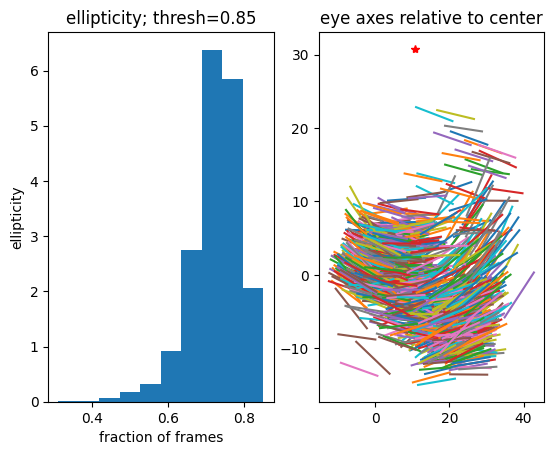

In [46]:

# Ellipticity histogram
fig_dwnsmpl = 100

try:
    # Hist of ellipticity
    plt.subplot(1,2,1)
    plt.hist(ellipticity, density=True)
    plt.title('ellipticity; thresh='+str(0.85))
    plt.ylabel('ellipticity')
    plt.xlabel('fraction of frames')
    
    # Eye axes relative to center
    w = ellipse[:,7]
    plt.subplot(1,2,2)
    for i in range(0,len(usegood_ellipcalb)):

        _show = usegood_ellipcalb[0][i::fig_dwnsmpl]

        plt.plot((ellipse[_show,11] + [-5 * np.cos(w[_show]),       \
                    5 * np.cos(w[_show])]),                            \
                    (ellipse[_show,12] + [-5*np.sin(w[_show]),         \
                    5*np.sin(w[_show])]))

    plt.plot(cam_cent[0], cam_cent[1], 'r*')
    plt.title('eye axes relative to center')

except Exception as e:
    print('Figure error in plots of ellipticity and axes relative to center')
    print(e)

In [76]:
# Check calibration
try:

    xvals = np.linalg.norm(ellipse[usegood_eyecalib, 11:13].T - cam_cent, axis=0)

    yvals = scale * np.sqrt( 1 - (ellipse[usegood_eyecalib, 6]              \
                                / ellipse[usegood_eyecalib, 5]) **2)

    calib_mask = ~np.isnan(xvals) & ~np.isnan(yvals)

    slope, _, r_value, _, _ = scipy.stats.linregress(xvals[calib_mask],
                                                        yvals[calib_mask].T)

except ValueError:
    print('no good frames that meet criteria... check DLC tracking!')

In [ ]:
# Check calibration
try:

    xvals = np.linalg.norm(data['ellipse'][data['usegood_eyecalib'], 11:13].T - cam_cent, axis=0)

    yvals = scale * np.sqrt( 1 - (data['ellipse'][data['usegood_eyecalib'], 6]              \
                                / data['ellipse'][data['usegood_eyecalib'], 5]) **2)

    calib_mask = ~np.isnan(xvals) & ~np.isnan(yvals)

    slope, _, r_value, _, _ = scipy.stats.linregress(xvals[calib_mask],
                                                        yvals[calib_mask].T)

except ValueError:
    print('no good frames that meet criteria... check DLC tracking!')
plt.figure()
plt.plot(xvals[::fig_dwnsmpl],
            yvals[::fig_dwnsmpl], '.', markersize=1)
plt.plot(np.linspace(0,50), np.linspace(0,50), 'r')
plt.title('scale={:.3} r={:.3} m={:.3}'.format(scale, r_value, slope))
plt.xlabel('pupil camera dist')
plt.ylabel('scale * ellipticity')

In [93]:
scale

50.319602277108295

Text(0, 0.5, 'fraction of frames')

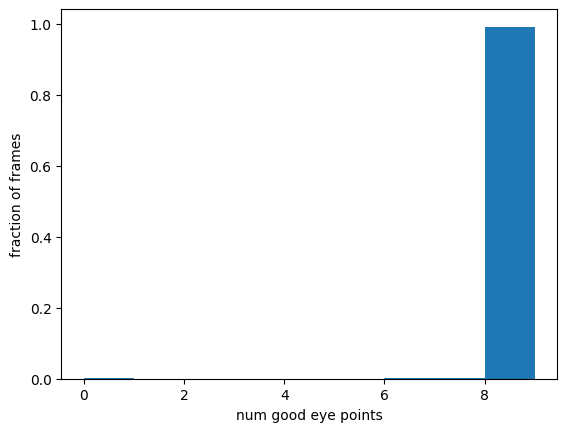

In [50]:
plt.figure()
plt.hist(pupil_count, bins=9,
                range=(0,9), density=True)
plt.xlabel('num good eye points')
plt.ylabel('fraction of frames')

(array([4.27246671e-07, 1.30687217e-06, 8.26847970e-06, 6.46901725e-05,
        2.66106819e-03, 2.72608508e-04, 1.65118272e-05, 5.32801731e-06,
        1.43253296e-06, 1.00528629e-07]),
 array([-1559.85793474, -1230.01460548,  -900.17127621,  -570.32794694,
         -240.48461767,    89.35871159,   419.20204086,   749.04537013,
         1078.88869939,  1408.73202866,  1738.57535793]),
 <BarContainer object of 10 artists>)

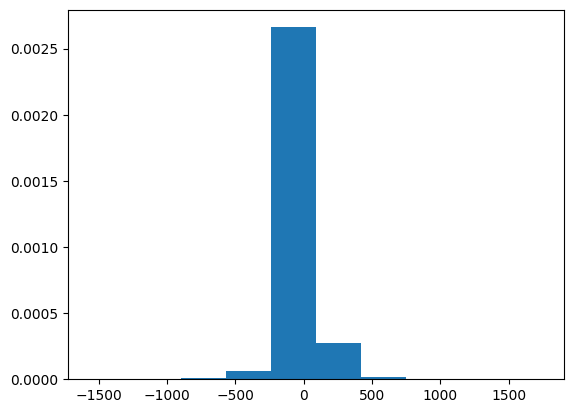

In [ ]:
plt.hist(dGaze,density = True)
plt.title('dGaze')

Text(0.5, 1.0, 'dEye_dps')

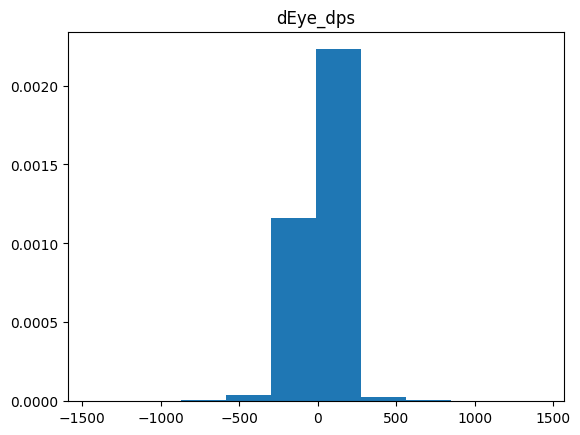

In [72]:
plt.hist(dEye_dps,density = True)
plt.title('dEye_dps')

(array([4.27246671e-07, 1.30687217e-06, 8.26847970e-06, 6.46901725e-05,
        2.66106819e-03, 2.72608508e-04, 1.65118272e-05, 5.32801731e-06,
        1.43253296e-06, 1.00528629e-07]),
 array([-1559.85793474, -1230.01460548,  -900.17127621,  -570.32794694,
         -240.48461767,    89.35871159,   419.20204086,   749.04537013,
         1078.88869939,  1408.73202866,  1738.57535793]),
 <BarContainer object of 10 artists>)

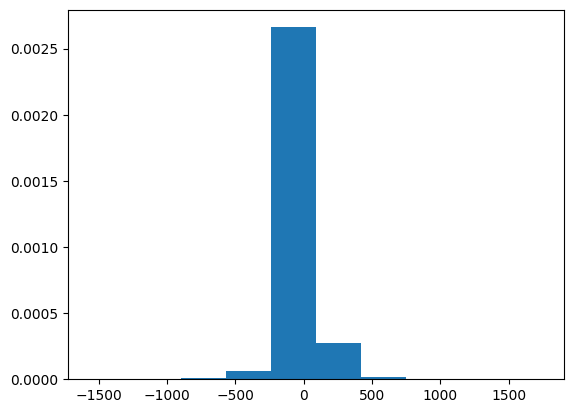

In [55]:
plt.hist(dGaze,density = True)

In [158]:
ellipse_out.values

array([[        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       ...,
       [ 0.1484882 , -0.69518718, 22.68823348, ..., 18.06013241,
        -1.10394807, -2.74508439],
       [ 0.14829436, -0.69700727, 22.61140428, ..., 18.05048578,
        -1.17437916, -2.73769255],
       [ 0.14883522, -0.69537608, 22.52338916, ..., 18.07740177,
        -1.10950993, -2.73241843]])

In [73]:
def save_imu_eye_data( ellipse_out,
    directory: str,
    animal: str,
    date: str = None,
    Usegood_reflec: bool = None,
    spot_count: int = None,
    ellipticity: int = None,
    usegood_ellipcalb: int = None,
    ellipse:np.ndarray= None,
    cam_cent:np.ndarray = None,
    pupil_count:np.ndarray = None,
    offset:np.ndarray = None,
    ccmax:np.ndarray = None,
    Openephys_time: np.ndarray = None,
    dEye_dps: np.ndarray = None,
    dHead: np.ndarray = None,
    imuT: np.ndarray = None,
    dGaze: np.ndarray = None,
    gazeL_event: np.ndarray = None,
    gazeL_idx: np.ndarray = None,
    gazeR_event: np.ndarray = None,
    gazeR_idx: np.ndarray = None,
    compL_event: np.ndarray = None,
    compL_idx: np.ndarray = None,
    compR_event: np.ndarray = None,
    compR_idx: np.ndarray = None,
    filename: str = None,
    **extra_data
) -> str:
    """
    Save sensor data in NumPy .npz format without timestamp.
    
    Args:
        directory: Path to save directory
        animal: Animal ID (required)
        date: Recording date (optional, defaults to current date)
        All parameters can be scalars or numpy arrays
        **extra_data: Additional data to include
        
    Returns:
        str: Full path to saved .npz file
    """
    # Create base dictionary
    data_dict = {
        'animal': np.array(animal),
        'date': np.array(date if date else datetime.now().strftime("%Y-%m-%d")),
    }
    
    # Add all sensor data
    sensor_params = {
        'Usegood_reflec': Usegood_reflec,
        'spot_count':spot_count,
        'ellipticity':ellipticity,
        'usegood_ellipcalb':usegood_ellipcalb,
        'ellipse':ellipse,
        'cam_cent':cam_cent,
        'pupil_count':pupil_count,
        'offset':offset,
        'ccmax':ccmax,
        'Openephys_time':Openephys_time,
        'dEye_dps': dEye_dps,
        'dHead': dHead,
        'imuT': imuT,
        'dGaze': dGaze,
        'gazeL_event': gazeL_event,
        'gazeL_idx': gazeL_idx,
        'gazeR_event': gazeR_event,
        'gazeR_idx': gazeR_idx,
        'compL_event': compL_event,
        'compL_idx': compL_idx,
        'compR_event': compR_event,
        'compR_idx': compR_idx,
        **extra_data
    }
    
    # Convert all values to numpy arrays
    for key, value in sensor_params.items():
        if value is not None:
            data_dict[key] = np.array(value)
    
    # Create directory if needed
    os.makedirs(directory, exist_ok=True)
    
    # Set default filename
    if filename is None:
        filename = f"{animal}_{data_dict['date'].item().replace('-', '')}.npz"
    elif not filename.endswith('.npz'):
        filename += '.npz'
    
    # Save in compressed numpy format
    filepath = os.path.join(directory, filename)
    np.savez_compressed(filepath, **data_dict)
    ellipse_out.to_netcdf(os.path.join(directory,str(animal)+'_elipse_params.nc'))

    
    return filepath

In [80]:
gazeL_event

array([4.40768000e-01, 1.60437800e+00, 1.95644800e+00, ...,
       2.06336933e+03, 2.06340132e+03, 2.06492156e+03])

In [74]:
animal_directory = Path(data_path / date / ani/ task)
save_imu_eye_data(directory=animal_directory,Openephys_time =Openephys_time,
                  animal=ani, date=date,Usegood_reflec=usegood_reflec,spot_count=spot_count,usegood_eyecalib = usegood_eyecalib, ellipticity=ellipticity,
                  usegood_ellipcalb=usegood_ellipcalb,ellipse=ellipse,cam_cent=cam_cent,pupil_count=pupil_count,
                  offset=offset,ccmax=ccmax,ellipse_out=ellipse_out,
                  dEye_dps=dEye_dps,dHead=dHead,imuT=imuT,dGaze=dGaze,gazeL_event=gazeL_event,gazeL_idx=gazeL_idx,gazeR_event= gazeR_event,gazeR_idx=gazeR_idx,
                  compL_event=compL_event,compL_idx=compL_idx,compR_event = compR_event, compR_idx=compR_idx, filename= str(date)+ "_"+str(ani)+"_imu_eyecam_dict")

'\\\\goeppert\\Vol2\\mike\\recordings\\050725\\F3LILT\\oa_cam\\050725_F3LILT_imu_eyecam_dict.npz'

In [75]:
test = xr.open_dataset(r"\\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\elipse_params.nc")

In [55]:
data = np.load(r"\\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_imu_eyecam_dict.npz",allow_pickle=True)

In [102]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats

def create_summary_figure(data_dict,  fig_dwnsmpl=100):
    """
    Create a 3x4 summary figure from eye tracking data (10 subplots, 2 empty).
    
    Parameters:
    -----------
    data_dict : dict
        Dictionary containing the eye tracking data with expected keys
    scale : float
        Scale parameter for calibration plot (default=1.0)
    fig_dwnsmpl : int
        Downsampling factor for some plots (default=100)
        
    Returns:
    --------
    fig : matplotlib.figure.Figure
        The created figure
    ax : array of matplotlib.axes.Axes
        Array of subplot axes

    """
    
    # Extract variables from dictionary
    pupil_count = data_dict['pupil_count']
    ellipticity = data_dict['ellipticity']
    usegood_ellipcalb = data_dict['usegood_ellipcalb']
    ellipse = data_dict['ellipse']
    cam_cent = data_dict['cam_cent']
    usegood_eyecalib = data_dict['usegood_eyecalib']
    dGaze = data_dict['dGaze']
    dEye_dps = data_dict['dEye_dps']
    dHead = data_dict['dHead']
    offset = data_dict['offset']
    ccmax = data_dict['ccmax']
    scale = data_dict['scale']

    try:
       f_lim = 50000
       if np.size(usegood_ellipcalb,1) > f_lim:
           shortlist = sorted(np.random.choice(usegood_ellipcalb[0],
                               size=f_lim, replace=False))
       else:
           shortlist = usegood_ellipcalb
       scale = np.nansum(np.sqrt(1 - (ellipticity)**2) *                       \
       (np.linalg.norm(ellipse[shortlist, 11:13] - cam_cent.T, axis=0)))       \
       / np.sum(1 - (ellipticity)**2)
    except ValueError:
        scale = np.nansum(np.sqrt(1 - (ellipticity)**2) *                       \
        (np.linalg.norm(ellipse[shortlist, 11:13] - cam_cent.T, axis=1)))       \
        / np.sum(1 - (ellipticity)**2)
    
    # Create figure and subplots (3 rows, 4 columns)
    fig, ax = plt.subplots(3, 4, figsize=(20, 15))
    
    # Plot 1: Histogram of pupil_count
    ax[0, 0].hist(pupil_count, bins=9, range=(0,9), density=True)
    ax[0, 0].set_xlabel('num good eye points')
    ax[0, 0].set_ylabel('fraction of frames')
    
    # Plot 2: Ellipticity histogram
    try:
        ax[0, 1].hist(ellipticity, density=True)
        ax[0, 1].set_title('ellipticity; thresh='+str(0.85))
        ax[0, 1].set_ylabel('ellipticity')
        ax[0, 1].set_xlabel('fraction of frames')
    except Exception as e:
        print('Figure error in ellipticity plot')
        print(e)
    
    # Plot 3: Eye axes relative to center
    try:
        w = ellipse[:,7]
        for i in range(0, len(usegood_ellipcalb)):
            _show = usegood_ellipcalb[0][i::fig_dwnsmpl]
            ax[0, 2].plot((ellipse[_show,11] + [-5 * np.cos(w[_show]), 5 * np.cos(w[_show])]),
                         (ellipse[_show,12] + [-5*np.sin(w[_show]), 5*np.sin(w[_show])]))
        
        ax[0, 2].plot(cam_cent[0], cam_cent[1], 'r*')
        ax[0, 2].set_title('eye axes relative to center')
    except Exception as e:
        print('Figure error in eye axes plot')
        print(e)
    
    # Plot 4: Calibration check
    try:
       
        
        xvals = np.linalg.norm(ellipse[usegood_eyecalib, 11:13].T - cam_cent, axis=0)
        yvals = scale * np.sqrt( 1 - (ellipse[usegood_eyecalib, 6]              \
                                / ellipse[usegood_eyecalib, 5]) **2)

        calib_mask = ~np.isnan(xvals) & ~np.isnan(yvals)
        slope, _, r_value, _, _ = scipy.stats.linregress(xvals[calib_mask],
                                                        yvals[calib_mask].T)

        
        ax[0, 3].plot(xvals[::fig_dwnsmpl], yvals[::fig_dwnsmpl], '.', markersize=1)
        ax[0, 3].plot(np.linspace(0,50), np.linspace(0,50), 'r')
        ax[0, 3].set_title('scale={:.3} r={:.3} m={:.3}'.format(scale, r_value, slope))
        ax[0, 3].set_xlabel('pupil camera dist')
        ax[0, 3].set_ylabel('scale * ellipticity')
    except Exception as e:
        print('Error in calibration plot')
        print(e)
    
    # Plot 5: dGaze histogram (first instance)
    ax[1, 0].hist(dHead, density=True)
    ax[1, 0].set_title('dHead (1)')
    
    # Plot 6: dEye_dps histogram
    ax[1, 1].hist(dEye_dps, density=True)
    ax[1, 1].set_title('dEye_dps')
    
    # Plot 7: dGaze histogram (second instance)
    ax[1, 2].hist(dGaze, density=True)
    ax[1, 2].set_title('dGaze (2)')
    
    # Plot 8: dEye vs dHead scatter
    ax[1, 3].plot(dEye_dps[::10], dHead[::10], 'k.', markersize=.7)
    ax[1, 3].set_xlabel('dEye')
    ax[1, 3].set_ylabel('dHead')
    ax[1, 3].set_xlim((-850,850))
    ax[1, 3].set_ylim((-850,850))
    ax[1, 3].plot([-850,850], [850,-850], 'r:')
    
    # Plot 9: Offset plot
    ax[2, 0].plot(offset)
    ax[2, 0].set_title('offset')
    
    # Plot 10: ccmax plot
    ax[2, 1].plot(ccmax)
    ax[2, 1].set_title('ccmax')
    
    # Turn off unused subplots (2 spaces remaining in 3x4 grid)
    ax[2, 2].axis('off')
    ax[2, 3].axis('off')
    
    # Adjust layout
    plt.tight_layout()
    
    return fig, ax

In [ ]:
fig.savefig(os.path.join(os.path.join(save_path,str(animal)+'_diagnostic.pdf')), format='pdf', bbox_inches='tight')

Text(0, 0.5, 'scale * ellipticity')

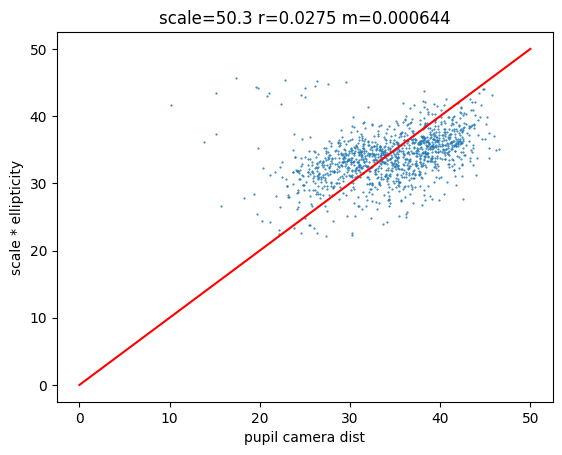

In [89]:
# Check calibration
try:

    xvals = np.linalg.norm(data['ellipse'][data['usegood_eyecalib'], 11:13].T - cam_cent, axis=0)

    yvals = scale * np.sqrt( 1 - (data['ellipse'][data['usegood_eyecalib'], 6]              \
                                / data['ellipse'][data['usegood_eyecalib'], 5]) **2)

    calib_mask = ~np.isnan(xvals) & ~np.isnan(yvals)

    slope, _, r_value, _, _ = scipy.stats.linregress(xvals[calib_mask],
                                                        yvals[calib_mask].T)

except ValueError:
    print('no good frames that meet criteria... check DLC tracking!')
plt.figure()
plt.plot(xvals[::fig_dwnsmpl],
            yvals[::fig_dwnsmpl], '.', markersize=1)
plt.plot(np.linspace(0,50), np.linspace(0,50), 'r')
plt.title('scale={:.3} r={:.3} m={:.3}'.format(scale, r_value, slope))
plt.xlabel('pupil camera dist')
plt.ylabel('scale * ellipticity')

In [95]:
data = np.load(
    r"\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\051225_F3LILT_imu_eyecam_dict.npz"
    ,allow_pickle=True)

In [97]:
data['scale']

array(42.88613695)

In [91]:
(np.linalg.norm(ellipse[shortlist, 11:13] - cam_cent.T, axis=0))

array([2462.56186648, 7411.75831322])

In [92]:
np.nansum(np.sqrt(1 - (ellipticity)**2) *                       \
---> 42    (np.linalg.norm(ellipse[shortlist, 11:13] - cam_cent.T, axis=0)))       \
     43    / np.sum(1 - (ellipticity)**2

SyntaxError: invalid syntax (2827381954.py, line 2)

In [ ]:
fig.savefig(os.path.join(os.path.join(save_path,str(animal)+'_diagnostic.pdf')), format='pdf', bbox_inches='tight')

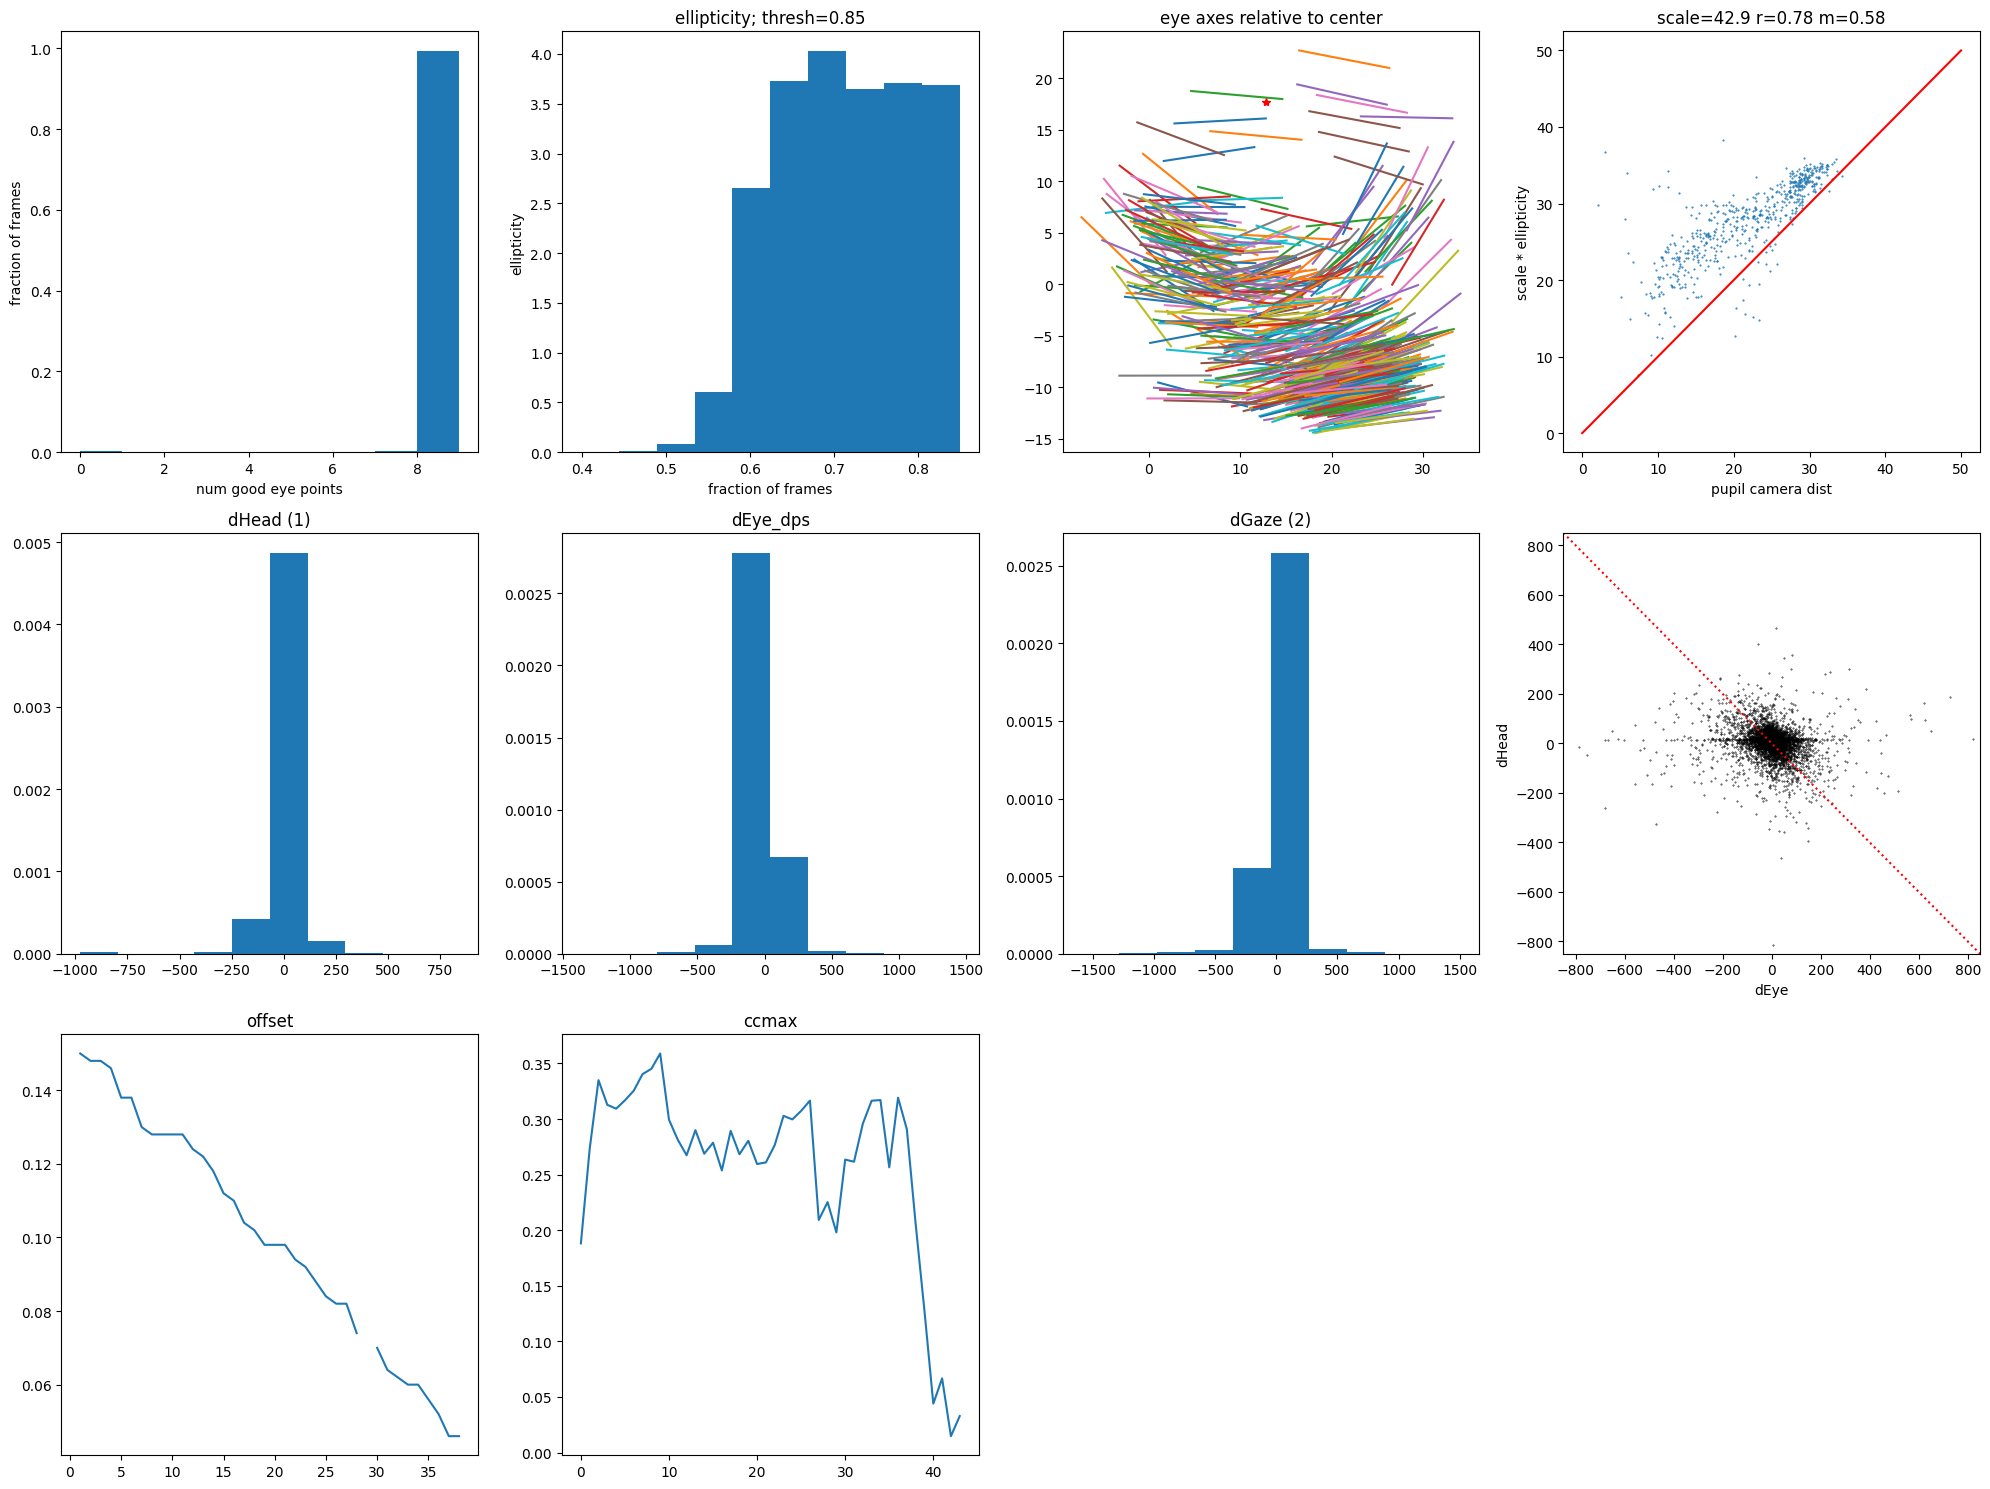

In [103]:
fig, ax = create_summary_figure(data)
plt.show()

In [2]:
dlc_h5 = [str(i) for i in list((data_path / date / ani/ task).rglob('*.h5')) if 'REYEdeinterDLC' in str(i)][0]
eye_timestamp_path = [str(i) for i in list((data_path / date / ani/ task).rglob('*.csv')) if 'REYE_BonsaiTS.csv' in str(i)][0]
pts, pt_names =open_dlc_h5(dlc_h5)
eyeT = read_timestamp_file(eye_timestamp_path, len(pts))
xrpts = xr.DataArray(pts, dims=['frame', 'point_loc'])

NameError: name 'data_path' is not defined

In [79]:
len(eyeT)

124408

In [8]:
test = xr.load_dataset(r"\\goeppert\Vol2\mike\recordings\050725\J731\oa_cam\J731_elipse_params.nc")


In [14]:
dlc_h5 = [str(i) for i in list((os.listdir(r'\\goeppert\Vol2\mike\recordings\050725\J731\oa_cam')).rglob('*.h5')) if 'REYEdeinterDLC' in str(i)][0]

AttributeError: 'list' object has no attribute 'rglob'

In [85]:
def eye_diagnostic_video(recording_path,video_path,recording_name,dlc_h5_path,ellipse_params):
        """ Plot video of eye tracking.
        """
        # Read in video, set up save file
        camname = 'eye'
        pts, pt_names =open_dlc_h5(dlc_h5_path)
        xrpts = xr.DataArray(pts, dims=['frame', 'point_loc'])
        vidread = cv2.VideoCapture(video_path)
        width = int(vidread.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(vidread.get(cv2.CAP_PROP_FRAME_HEIGHT))
        _vidname = '{}_{}_plot.avi'.format(recording_name, camname)
        savepath = os.path.join(recording_path, _vidname)
        fourcc = cv2.VideoWriter_fourcc(*'XVID')
        out_vid = cv2.VideoWriter(savepath, fourcc, 60.0, (width, height))
        # Only do the first number of frames (limit of frames to use should
        # be set in cfg dict)
        nFrames = int(vidread.get(cv2.CAP_PROP_FRAME_COUNT))
        # Iterate through frames
        for frame_num in tqdm(range(nFrames)):
            # Read frame and make sure it's read in correctly
            ret, frame = vidread.read()
            if not ret:
                break
            # Plot on the frame if there is data to be used
            if xrpts is not None and ellipse_params is not None:
                try:
                    # Get out ellipse long/short axes and put into tuple
                    ellipse_axes = (int(ellipse_params.sel(                        \
                                        frame=frame_num,                                \
                                        ellipse_params='longaxis').to_array().values[0]),             \
                                    int(ellipse_params.sel(                        \
                                        frame=frame_num,                                \
                                        ellipse_params='shortaxis').to_array().values[0]))
                    # Get out ellipse phi and round to int
                    # Note: this is ellipse_phi not phi
                    ellipse_phi = int(np.rad2deg(ellipse_params.sel(
                                        frame=frame_num,
                                        ellipse_params='ellipse_phi').to_array().values[0]))
                    # Get ellipse center out, round to int, and put into tuple
                    ellipse_cent = (int(ellipse_params.sel(
                                        frame=frame_num,
                                        ellipse_params='X0').to_array().values[0]),
                                    int(ellipse_params.sel(
                                        frame=frame_num,
                                        ellipse_params='Y0').to_array().values[0]))
                    # Update this frame with an ellipse
                    # ellipse plotted in blue
                    frame = cv2.ellipse(frame, ellipse_cent, ellipse_axes,
                                        ellipse_phi, 0, 360, (255,0,0), 2)
                # Skip if the ell data from this frame are bad
                except (ValueError, KeyError):
                    pass
                try:
                    # iterate through each point in the list
                    for k in range(0, len(xrpts.isel(frame=frame_num)), 3):
                        # get the point center of each point num, k
                        pt_cent = (int(xrpts.isel(frame=frame_num,
                                                       point_loc=k).values),
                                   int(xrpts.isel(frame=frame_num,
                                                       point_loc=k+1).values))
                        # compare to threshold set in cfg and plot
                        if xrpts.isel(frame=frame_num, point_loc=k+2).values < 0.99:
                            # bad points in red
                            frame = cv2.circle(frame, pt_cent, 3, (0,0,255), -1)
                        elif xrpts.isel(frame=frame_num, point_loc=k+2).values >= 0.99:
                            # good points in green
                            frame = cv2.circle(frame, pt_cent, 3, (0,255,0), -1)
                except (ValueError, KeyError):
                    pass
            out_vid.write(frame)
        out_vid.release()

In [90]:
recording_path = r'\\goeppert\Vol2\mike\recordings\050725\J731\oa_cam'
video_path = r"\\goeppert\Vol2\mike\recordings\050725\J731\oa_cam\050725_J731_control_Rig2_oa_cam_REYEdeinter.avi"
recording_name = 'J731_050725'
dlc_h5_path = r"\\goeppert\Vol2\mike\recordings\050725\J731\oa_cam\050725_J731_control_Rig2_oa_cam_REYEdeinterDLC_resnet50_eye_tracking_050825May8shuffle1_1030000.h5"
ellipse_params =  xr.load_dataset(r"\\goeppert\Vol2\mike\recordings\050725\J731\oa_cam\J731_elipse_params.nc")

eye_diagnostic_video(recording_path,video_path,recording_name,dlc_h5_path,ellipse_params)

100%|██████████| 65922/65922 [09:22<00:00, 117.15it/s]


In [86]:
recording_path = r'\\goeppert\Vol2\mike\recordings\050825\J731\oa_cam1'
video_path = r"\\goeppert\Vol2\mike\recordings\050825\J731\oa_cam1\050825_J731_control_Rig2_oa_cam1_REYEdeinter.avi"
recording_name = 'J731_050825'
dlc_h5_path = r"\\goeppert\Vol2\mike\recordings\050825\J731\oa_cam1\050825_J731_control_Rig2_oa_cam1_REYEdeinterDLC_resnet50_eye_tracking_050825May8shuffle1_1030000.h5"
ellipse_params =  xr.load_dataset(r"\\goeppert\Vol2\mike\recordings\050825\J731\oa_cam1\J731_elipse_params.nc")

eye_diagnostic_video(recording_path,video_path,recording_name,dlc_h5_path,ellipse_params)

100%|██████████| 71406/71406 [09:34<00:00, 124.30it/s]


In [89]:
recording_path = r'\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam'
video_path = r"\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\051225_F3LILT_control_Rig2_oa_cam_REYEdeinter.avi"
recording_name = 'F3LILT_051225'
dlc_h5_path = r"\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\051225_F3LILT_control_Rig2_oa_cam_REYEdeinterDLC_resnet50_eye_tracking_050825May8shuffle1_1030000.h5"
ellipse_params =  xr.load_dataset(r"\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\F3LILT_elipse_params.nc")

eye_diagnostic_video(recording_path,video_path,recording_name,dlc_h5_path,ellipse_params)

100%|██████████| 59496/59496 [09:12<00:00, 107.76it/s]


In [79]:
xrpts.isel(frame=frame_num,
                                                       point_loc=k+1).values

array(312.29281616)

In [74]:
pt_cent = (int(xrpts.isel(frame=frame_num,
                                                       point_loc=k).values()),
                                   int(xrpts.isel(frame=frame_num,
                                                       point_loc=k+1).values()))

TypeError: 'numpy.ndarray' object is not callable

In [66]:
for k in range(0, len(xrpts.isel(frame=frame_num)), 3):
                # get the point center of each point num, k
                pt_cent = (int(xrpts.isel(frame=frame_num,
                                               point_loc=k).values),
                           int(xrpts.isel(frame=frame_num,
                                               point_loc=k+1).values))
                # compare to threshold set in cfg and plot
                if xrpts.isel(frame=frame_num, point_loc=k+2).values < 0.99:
                    # bad points in red
                    frame = cv2.circle(frame, pt_cent, 3, (0,0,255), -1)
                elif xrpts.isel(frame=frame_num, point_loc=k+2).values >= 0.99:
                    # good points in green
                    frame = cv2.circle(frame, pt_cent, 3, (0,255,0), -1)

In [ ]:
camname = 'eye'
pts, pt_names =open_dlc_h5(dlc_h5_path)
xrpts = xr.DataArray(pts, dims=['frame', 'point_loc'])
vidread = cv2.VideoCapture(video_path)
width = int(vidread.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(vidread.get(cv2.CAP_PROP_FRAME_HEIGHT))
_vidname = '{}_{}_plot.avi'.format(recording_name, camname)
savepath = os.path.join(recording_path, _vidname)
fourcc = cv2.VideoWriter_fourcc(*'XVID')
out_vid = cv2.VideoWriter(savepath, fourcc, 60.0, (width, height))
# Only do the first number of frames (limit of frames to use should
# be set in cfg dict)
nFrames = int(vidread.get(cv2.CAP_PROP_FRAME_COUNT))
# Iterate through frames
for frame_num in tqdm(range(nFrames)):
    # Read frame and make sure it's read in correctly
    ret, frame = vidread.read()
    if not ret:
        break
    # Plot on the frame if there is data to be used
    if xrpts is not None and ellipse_params is not None:
        try:
            # Get out ellipse long/short axes and put into tuple
            ellipse_axes = (int(ellipse_params.sel(                        \
                                frame=frame_num,                                \
                                ellipse_params='longaxis').values),             \
                            int(ellipse_params.sel(                        \
                                frame=frame_num,                                \
                                ellipse_params='shortaxis').values))
            # Get out ellipse phi and round to int
            # Note: this is ellipse_phi not phi
            ellipse_phi = int(np.rad2deg(ellipse_params.sel(
                                frame=frame_num,
                                ellipse_params='ellipse_phi').values))
            # Get ellipse center out, round to int, and put into tuple
            ellipse_cent = (int(ellipse_params.sel(
                                frame=frame_num,
                                ellipse_params='X0').values),
                            int(ellipse_params.sel(
                                frame=frame_num,
                                ellipse_params='Y0').values))
            # Update this frame with an ellipse
            # ellipse plotted in blue
            frame = cv2.ellipse(frame, ellipse_cent, ellipse_axes,
                                ellipse_phi, 0, 360, (255,0,0), 2)
        # Skip if the ell data from this frame are bad
        except (ValueError, KeyError):
            pass
        try:
            # iterate through each point in the list
            for k in range(0, len(xrpts.isel(frame=frame_num)), 3):
                # get the point center of each point num, k
                pt_cent = (int(xrpts.isel(frame=frame_num,
                                               point_loc=k).values),
                           int(xrpts.isel(frame=frame_num,
                                               point_loc=k+1).values))
                # compare to threshold set in cfg and plot
                if xrpts.isel(frame=frame_num, point_loc=k+2).values < 0.99:
                    # bad points in red
                    frame = cv2.circle(frame, pt_cent, 3, (0,0,255), -1)
                elif xrpts.isel(frame=frame_num, point_loc=k+2).values >= 0.99:
                    # good points in green
                    frame = cv2.circle(frame, pt_cent, 3, (0,255,0), -1)
        except (ValueError, KeyError):
            pass
    out_vid.write(frame)
out_vid.release()

  0%|          | 0/65922 [00:00<?, ?it/s]


TypeError: int() argument must be a string, a bytes-like object or a number, not 'method'